# EDA — Análise Exploratória de Dados

> **Tech Challenge — Telco Customer Churn Prediction**  
> Objetivo: entender o dataset, identificar padrões de churn e **justificar a escolha das métricas de avaliação**.


In [ ]:
import os, sys
from pathlib import Path


def _find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start


ROOT = _find_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DOCS = ROOT / "src" / "docs"
DOCS.mkdir(exist_ok=True)

df_raw = pd.read_csv(ROOT / "src" / "data" / "churn.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 1. Qualidade e estrutura dos dados

In [ ]:
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.drop(columns=["customerID"], inplace=True, errors="ignore")
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(f"Shape após limpeza : {df.shape}")
print(f"Nulos restantes    : {df.isnull().sum().sum()}")
print(f"\nTipos de coluna:")
print(df.dtypes.value_counts())
df.describe()

Shape após limpeza : (7032, 20)
Nulos restantes    : 0

Tipos de coluna:
object     15
int64       3
float64     2
Name: count, dtype: int64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## 2. Distribuição do alvo — e por que Accuracy não é a métrica certa

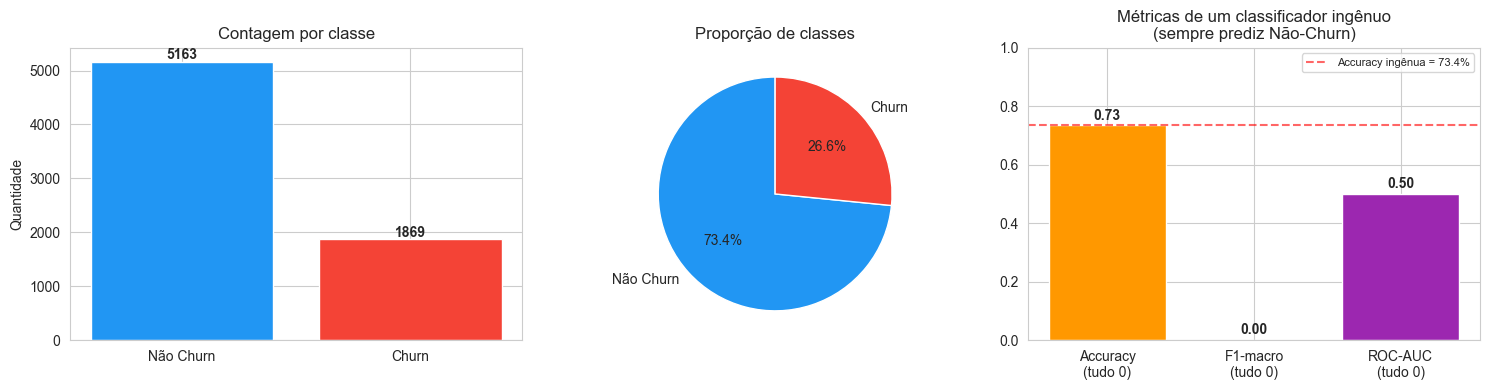


>> Taxa de churn: 26.6%
>> Accuracy de um modelo sempre-0: 73.4%
>> Conclusão: Accuracy é ENGANOSA aqui. Usar F1-macro e ROC-AUC.


In [ ]:
churn_rate = df["Churn"].mean()
baseline_acc = 1 - churn_rate

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df["Churn"].value_counts()
axes[0].bar(["Não Churn", "Churn"], counts.values, color=["#2196F3", "#F44336"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")
axes[0].set_title("Contagem por classe")
axes[0].set_ylabel("Quantidade")

axes[1].pie(
    counts.values,
    labels=["Não Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["#2196F3", "#F44336"],
    startangle=90,
)
axes[1].set_title("Proporção de classes")

metrics_naive = {
    "Accuracy\n(tudo 0)": baseline_acc,
    "F1-macro\n(tudo 0)": 0.0,
    "ROC-AUC\n(tudo 0)": 0.5,
}
bars = axes[2].bar(
    metrics_naive.keys(), metrics_naive.values(), color=["#FF9800", "#4CAF50", "#9C27B0"]
)
axes[2].axhline(
    baseline_acc,
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Accuracy ingênua = {baseline_acc:.1%}",
)
axes[2].set_ylim(0, 1)
axes[2].set_title("Métricas de um classificador ingênuo\n(sempre prediz Não-Churn)")
axes[2].legend(fontsize=8)
for bar, val in zip(bars, metrics_naive.values()):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center", fontweight="bold"
    )

plt.tight_layout()
plt.savefig(DOCS / "eda_churn_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n>> Taxa de churn: {churn_rate:.1%}")
print(f">> Accuracy de um modelo sempre-0: {baseline_acc:.1%}")
print(">> Conclusão: Accuracy é ENGANOSA aqui. Usar F1-macro e ROC-AUC.")

## 3. Variáveis numéricas — distribuição por classe

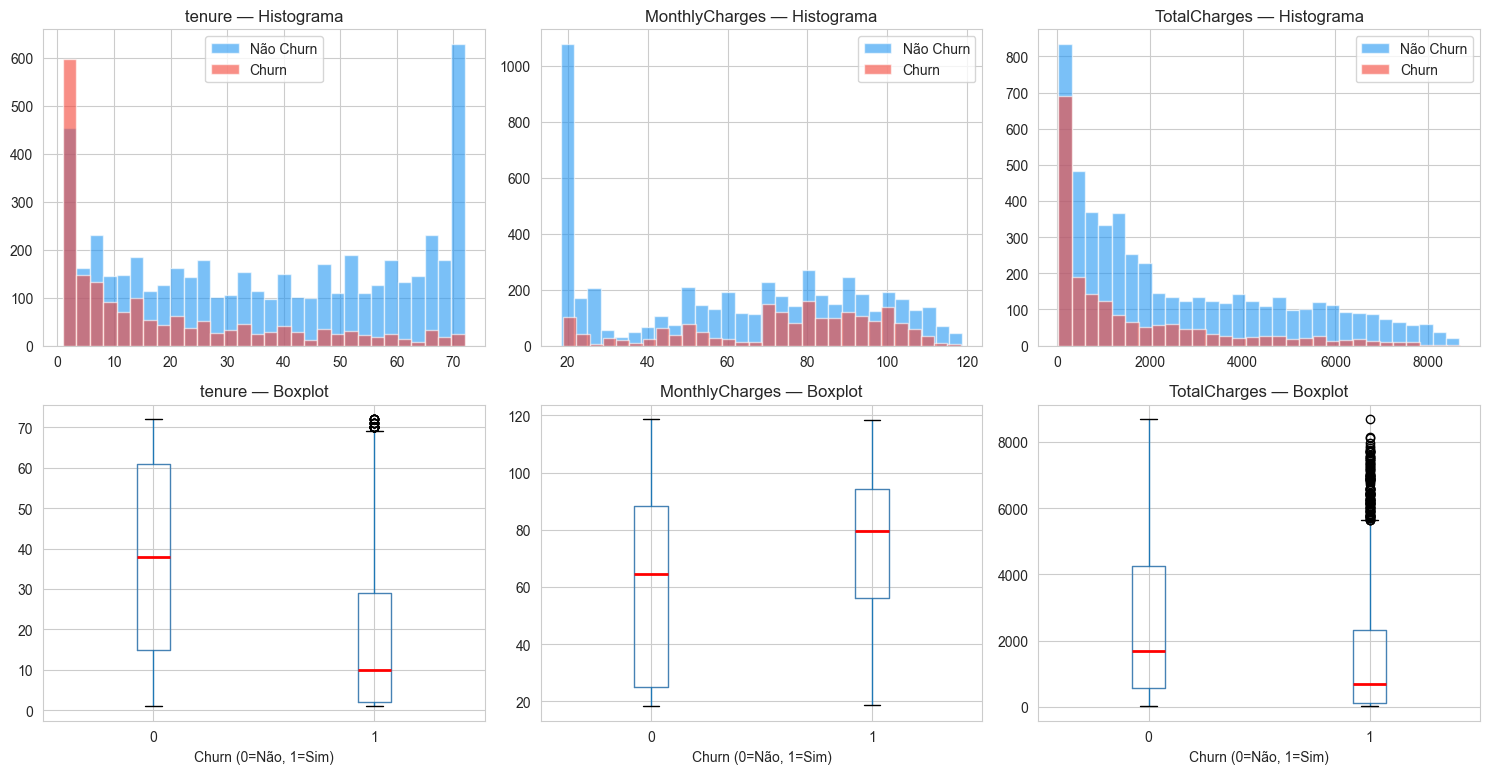

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    for label, color in [(0, "#2196F3"), (1, "#F44336")]:
        axes[0, i].hist(
            df[df["Churn"] == label][col],
            alpha=0.6,
            label=["Não Churn", "Churn"][label],
            color=color,
            bins=30,
        )
    axes[0, i].set_title(f"{col} — Histograma")
    axes[0, i].legend()
    df.boxplot(
        column=col,
        by="Churn",
        ax=axes[1, i],
        boxprops=dict(color="steelblue"),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[1, i].set_title(f"{col} — Boxplot")
    axes[1, i].set_xlabel("Churn (0=Não, 1=Sim)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(DOCS / "eda_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Variáveis categóricas — taxa de churn por grupo

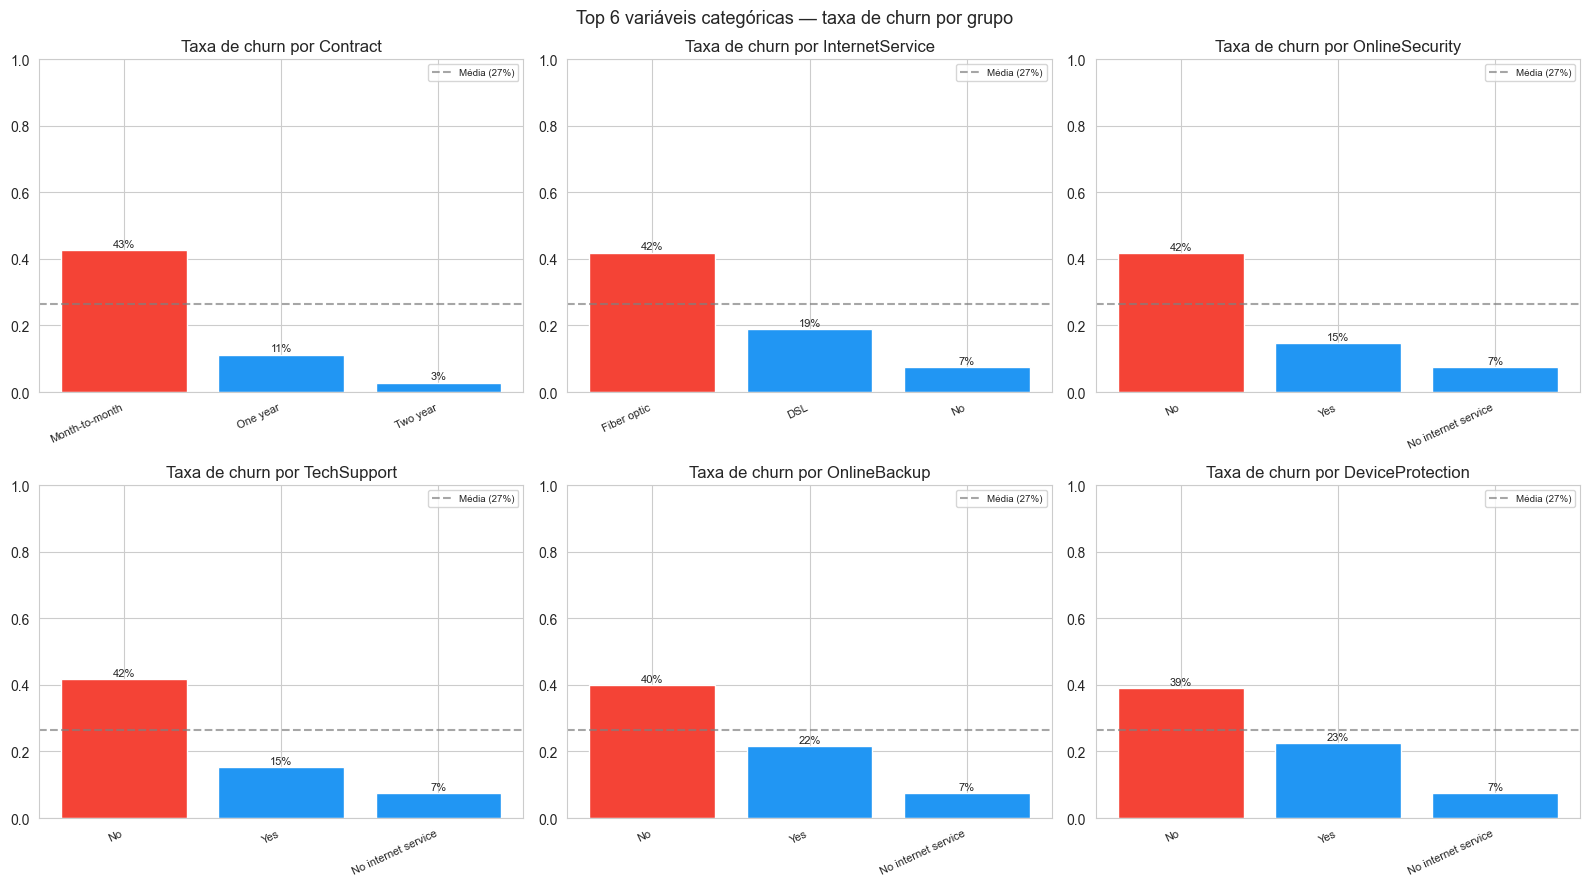

In [ ]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
churn_rates_var = {col: df.groupby(col)["Churn"].mean() for col in cat_cols}
top_cats = sorted(
    churn_rates_var, key=lambda c: churn_rates_var[c].max() - churn_rates_var[c].min(), reverse=True
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    rates = churn_rates_var[col].sort_values(ascending=False)
    bars = axes[i].bar(
        rates.index, rates.values, color=["#F44336" if v > 0.3 else "#2196F3" for v in rates.values]
    )
    axes[i].axhline(
        churn_rate, color="grey", linestyle="--", alpha=0.7, label=f"Média ({churn_rate:.0%})"
    )
    axes[i].set_title(f"Taxa de churn por {col}")
    axes[i].set_xticklabels(rates.index, rotation=25, ha="right", fontsize=8)
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=7)
    for bar, val in zip(bars, rates.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.0%}", ha="center", fontsize=8
        )

plt.suptitle("Top 6 variáveis categóricas — taxa de churn por grupo", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS / "eda_categoricas_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Correlação das features numéricas com o alvo

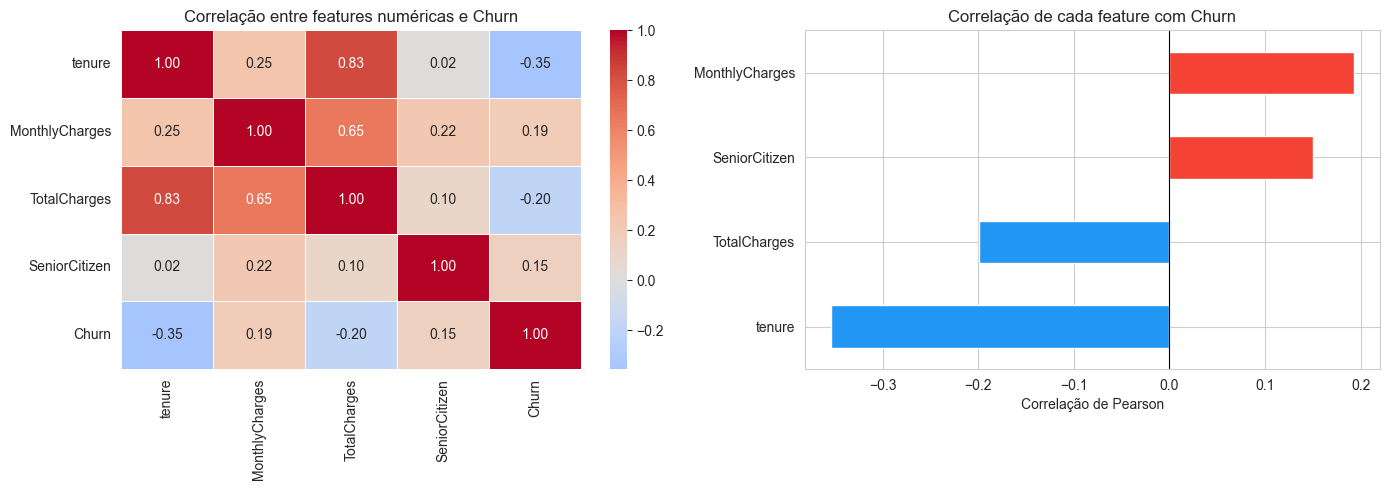

tenure (-): clientes mais antigos churnam menos
MonthlyCharges (+): cobranças maiores -> mais churn


In [ ]:
num_df = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]]
corr = num_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title("Correlação entre features numéricas e Churn")

churn_corr = corr["Churn"].drop("Churn").sort_values()
colors = ["#F44336" if v > 0 else "#2196F3" for v in churn_corr.values]
churn_corr.plot(kind="barh", ax=axes[1], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlação de cada feature com Churn")
axes[1].set_xlabel("Correlação de Pearson")

plt.tight_layout()
plt.savefig(DOCS / "eda_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("tenure (-): clientes mais antigos churnam menos")
print("MonthlyCharges (+): cobranças maiores -> mais churn")

## 6. Análise de tenure por faixas — quando o cliente está em risco?

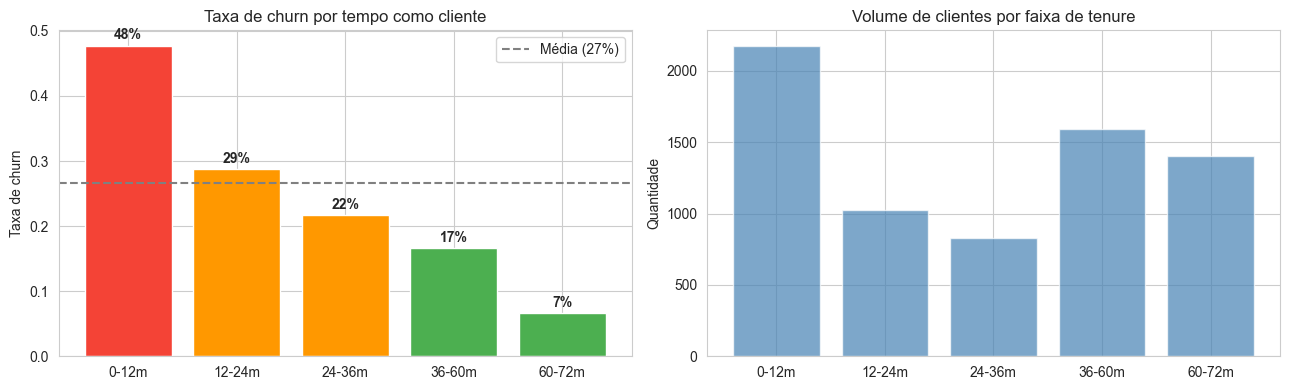

Insight: clientes nos primeiros 12 meses têm risco muito acima da média.


In [ ]:
df["tenure_faixa"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 60, 72],
    labels=["0-12m", "12-24m", "24-36m", "36-60m", "60-72m"],
    include_lowest=True,
)

faixa_stats = (
    df.groupby("tenure_faixa", observed=True)
    .agg(n_clientes=("Churn", "count"), taxa_churn=("Churn", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(
    faixa_stats["tenure_faixa"].astype(str),
    faixa_stats["taxa_churn"],
    color=[
        "#F44336" if v > 0.35 else "#FF9800" if v > 0.2 else "#4CAF50"
        for v in faixa_stats["taxa_churn"]
    ],
)
axes[0].axhline(churn_rate, color="grey", linestyle="--", label=f"Média ({churn_rate:.0%})")
axes[0].set_title("Taxa de churn por tempo como cliente")
axes[0].set_ylabel("Taxa de churn")
axes[0].legend()
for i, row in faixa_stats.iterrows():
    axes[0].text(
        i, row["taxa_churn"] + 0.01, f"{row['taxa_churn']:.0%}", ha="center", fontweight="bold"
    )

axes[1].bar(
    faixa_stats["tenure_faixa"].astype(str), faixa_stats["n_clientes"], color="steelblue", alpha=0.7
)
axes[1].set_title("Volume de clientes por faixa de tenure")
axes[1].set_ylabel("Quantidade")

plt.tight_layout()
plt.savefig(DOCS / "eda_tenure_faixas.png", dpi=150, bbox_inches="tight")
plt.show()
df.drop(columns=["tenure_faixa"], inplace=True)
print("Insight: clientes nos primeiros 12 meses têm risco muito acima da média.")

## 7. Conclusão — justificativa das métricas

In [ ]:
print("=" * 60)
print("  RESUMO DA EDA — Telco Customer Churn")
print("=" * 60)
print(f"""
Dataset
  Registros   : {len(df):,} clientes
  Features    : {df.shape[1] - 1}
  Churn rate  : {churn_rate:.1%} (desbalanceado)

Padrões principais
  - Contrato mensal  : {df[df["Contract"] == "Month-to-month"]["Churn"].mean():.0%} de churn
  - Contrato anual+  : {df[df["Contract"].isin(["One year", "Two year"])]["Churn"].mean():.0%} de churn
  - Primeiros 12 meses: maior risco
  - Sem OnlineSecurity/TechSupport: mais churn

Métricas escolhidas
  x Accuracy  : modelo zerado atinge {baseline_acc:.1%} — inútil
  v ROC-AUC   : separabilidade independente do threshold
  v F1-macro  : penaliza desequilíbrio de classes
  v Precision : custo de ofertas desnecessárias (FP)
  v Recall    : custo de churns não detectados (FN)
""")

  RESUMO DA EDA — Telco Customer Churn

Dataset
  Registros   : 7,032 clientes
  Features    : 19
  Churn rate  : 26.6% (desbalanceado)

Padrões principais
  - Contrato mensal  : 43% de churn
  - Contrato anual+  : 7% de churn
  - Primeiros 12 meses: maior risco
  - Sem OnlineSecurity/TechSupport: mais churn

Métricas escolhidas
  x Accuracy  : modelo zerado atinge 73.4% — inútil
  v ROC-AUC   : separabilidade independente do threshold
  v F1-macro  : penaliza desequilíbrio de classes
  v Precision : custo de ofertas desnecessárias (FP)
  v Recall    : custo de churns não detectados (FN)



: 